# 03 — EDA and Weather Trend Analysis

This notebook explores the cleaned and feature-engineered weather dataset stored in DuckDB as `analytics.model_features`.

The goal is to understand city-level weather patterns, seasonal trends, tourism-relevant risks, and relationships between weather variables before modeling.

The main focus is on outdoor tourism planning, especially the May–June period.

## 1. Imports & Setup


In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.db import run_query

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Load Model-Ready Data


In [2]:
df = run_query("SELECT * FROM analytics.model_features").copy()

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["city", "time"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["time"].min(), "→", df["time"].max())
print("Cities:", df["city"].unique())

df.head()

Shape: (10955, 20)
Date range: 2020-04-28 00:00:00 → 2026-04-27 00:00:00
Cities: ['Baku' 'Gabala' 'Guba' 'Lankaran' 'Shaki']


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,day_of_month,temperature_lag_1,precipitation_lag_1,wind_lag_1,humidity_lag_1,temperature_3d_avg,precipitation_7d_sum,wind_3d_avg,humidity_7d_avg,city_encoded
0,2020-04-28,14.6,0.0,42.0,83,71,11.9,38436.84,Baku,4,28,19.3,0.0,15.9,78.0,16.950000,0.0,28.950000,80.500000,0
1,2020-04-29,17.6,0.0,22.4,61,50,16.3,39311.92,Baku,4,29,14.6,0.0,42.0,83.0,17.166667,0.0,26.766667,74.000000,0
2,2020-04-30,18.0,0.0,23.0,77,50,16.0,44363.33,Baku,4,30,17.6,0.0,22.4,61.0,16.733333,0.0,29.133333,74.750000,0
3,2020-05-01,19.5,0.0,20.2,78,24,18.5,46341.87,Baku,5,1,18.0,0.0,23.0,77.0,18.366667,0.0,21.866667,75.400000,0
4,2020-05-02,19.6,0.0,20.7,83,45,19.0,43993.52,Baku,5,2,19.5,0.0,20.2,78.0,19.033333,0.0,21.300000,76.666667,0


## 3. Basic Dataset Overview


### 3.1 — structure

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10955 entries, 0 to 10954
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   time                       10955 non-null  datetime64[ns]
 1   temperature_2m_max         10955 non-null  float64       
 2   precipitation_sum          10955 non-null  float64       
 3   wind_speed_10m_max         10955 non-null  float64       
 4   relative_humidity_2m_mean  10955 non-null  int64         
 5   cloud_cover_mean           10955 non-null  int64         
 6   apparent_temperature_max   10955 non-null  float64       
 7   sunshine_duration          10955 non-null  float64       
 8   city                       10955 non-null  object        
 9   month                      10955 non-null  int32         
 10  day_of_month               10955 non-null  int32         
 11  temperature_lag_1          10955 non-null  float64       
 12  prec

### 3.2 — missing values and city counts

In [4]:
print("Missing values:")
display(df.isna().sum())

print("\nRows per city:")
display(df["city"].value_counts())

Missing values:


time                         0
temperature_2m_max           0
precipitation_sum            0
wind_speed_10m_max           0
relative_humidity_2m_mean    0
cloud_cover_mean             0
apparent_temperature_max     0
sunshine_duration            0
city                         0
month                        0
day_of_month                 0
temperature_lag_1            0
precipitation_lag_1          0
wind_lag_1                   0
humidity_lag_1               0
temperature_3d_avg           0
precipitation_7d_sum         0
wind_3d_avg                  0
humidity_7d_avg              0
city_encoded                 0
dtype: int64


Rows per city:


city
Baku        2191
Gabala      2191
Guba        2191
Lankaran    2191
Shaki       2191
Name: count, dtype: int64

## 4. City-Level Weather Summary


### 4.1 — target columns

In [5]:
target_cols = [
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_max",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
]

city_summary = (
    df.groupby("city")[target_cols]
    .agg(["mean", "median", "std", "min", "max"])
)

city_summary

temperature_2m_max                               precipitation_sum  \
                       mean median        std   min   max              mean   
city                                                                          
Baku              19.585121   19.2   9.321730  -1.0  40.0          0.914879   
Gabala            21.960338   21.8  10.310553   0.1  42.4          1.021451   
Guba              16.327476   16.4  10.139258 -10.4  39.0          1.810361   
Lankaran          19.398859   19.2   8.060575  -0.1  36.5          2.647010   
Shaki             19.453081   19.5   9.454744  -1.4  38.5          2.124144   

                                       ... relative_humidity_2m_mean         \
         median       std  min    max  ...                      mean median   
city                                   ...                                    
Baku        0.0  3.260132  0.0   70.6  ...                 72.303514   73.0   
Gabala      0.0  3.283500  0.0   48.9  ...                 64.424007   66.0   
Guba        0.0  4.577704  0.0   93.2  ...                 69.918302   71.0   
Lankaran    0.0  7.438140  0.0  144.5  ...                 76.666819   78.0   
Shaki       0.0  5.928062  0.0   83.2  ...                 68.844820   70.0   

                            cloud_cover_mean                             
                std min max             mean median        std min  max  
city                                                                     
Baku      11.789810  32  97        48.426289   47.0  34.358171   0  100  
Gabala    17.045616  21  99        45.455956   43.0  31.718824   0  100  
Guba      16.205506  14  99        56.380192   59.0  33.548481   0  100  
Lankaran  11.045088  39  99        52.612962   52.0  35.162063   0  100  
Shaki     14.847462  22  99        48.326791   46.0  32.109189   0  100  

[5 rows x 25 columns]

### 4.2 — simpler tourism summary

In [6]:
tourism_summary = df.groupby("city").agg(
    avg_temp=("temperature_2m_max", "mean"),
    avg_precipitation=("precipitation_sum", "mean"),
    rainy_days=("precipitation_sum", lambda x: (x > 1).mean()),
    avg_wind=("wind_speed_10m_max", "mean"),
    avg_humidity=("relative_humidity_2m_mean", "mean"),
    avg_cloud_cover=("cloud_cover_mean", "mean"),
).reset_index()

tourism_summary["rainy_days_pct"] = tourism_summary["rainy_days"] * 100
tourism_summary = tourism_summary.drop(columns="rainy_days")

tourism_summary

,city,avg_temp,avg_precipitation,avg_wind,avg_humidity,avg_cloud_cover,rainy_days_pct
0,Baku,19.585121,0.914879,23.608261,72.303514,48.426289,16.430853
1,Gabala,21.960338,1.021451,15.314696,64.424007,45.455956,16.795984
2,Guba,16.327476,1.810361,13.216568,69.918302,56.380192,30.625285
3,Lankaran,19.398859,2.647010,14.061844,76.666819,52.612962,27.658603
4,Shaki,19.453081,2.124144,11.978549,68.844820,48.326791,24.646280


## 5. Seasonal Focus: May–June Tourism Window


### 5.1 — filter May–June

In [7]:
may_june_df = df[df["month"].isin([5, 6])].copy()

print("May–June shape:", may_june_df.shape)
print("Date range:", may_june_df["time"].min(), "→", may_june_df["time"].max())

may_june_df.head()

May–June shape: (1830, 20)
Date range: 2020-05-01 00:00:00 → 2025-06-30 00:00:00


,time,temperature_2m_max,precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean,cloud_cover_mean,apparent_temperature_max,sunshine_duration,city,month,day_of_month,temperature_lag_1,precipitation_lag_1,wind_lag_1,humidity_lag_1,temperature_3d_avg,precipitation_7d_sum,wind_3d_avg,humidity_7d_avg,city_encoded
3,2020-05-01,19.5,0.0,20.2,78,24,18.5,46341.87,Baku,5,1,18.0,0.0,23.0,77.0,18.366667,0.0,21.866667,75.400000,0
4,2020-05-02,19.6,0.0,20.7,83,45,19.0,43993.52,Baku,5,2,19.5,0.0,20.2,78.0,19.033333,0.0,21.300000,76.666667,0
5,2020-05-03,22.9,1.3,14.9,81,52,26.2,44030.64,Baku,5,3,19.6,0.0,20.7,83.0,20.666667,1.3,18.600000,77.285714,0
6,2020-05-04,22.5,0.0,23.3,76,43,22.3,46191.04,Baku,5,4,22.9,1.3,14.9,81.0,21.666667,1.3,19.633333,77.000000,0
7,2020-05-05,25.8,0.0,21.6,62,85,24.7,33037.54,Baku,5,5,22.5,0.0,23.3,76.0,23.733333,1.3,19.933333,74.000000,0


### 5.2 — May–June summary

In [8]:
may_june_summary = may_june_df.groupby("city").agg(
    avg_temp=("temperature_2m_max", "mean"),
    avg_precipitation=("precipitation_sum", "mean"),
    rainy_days_pct=("precipitation_sum", lambda x: (x > 1).mean() * 100),
    avg_wind=("wind_speed_10m_max", "mean"),
    avg_humidity=("relative_humidity_2m_mean", "mean"),
    avg_cloud_cover=("cloud_cover_mean", "mean"),
).reset_index()

may_june_summary.sort_values("avg_temp", ascending=False)

,city,avg_temp,avg_precipitation,rainy_days_pct,avg_wind,avg_humidity,avg_cloud_cover
1,Gabala,29.773224,1.453005,19.945355,17.189891,54.524590,41.994536
4,Shaki,26.322951,3.619126,34.972678,12.346995,65.336066,47.273224
0,Baku,25.825410,0.762842,14.754098,24.662568,65.912568,35.237705
3,Lankaran,24.743989,1.416940,20.765027,15.064481,74.508197,41.494536
2,Guba,23.315847,1.905191,31.967213,14.694262,63.030055,52.371585


## 6. Weather Trends by City


### 6.1 — temperature trend

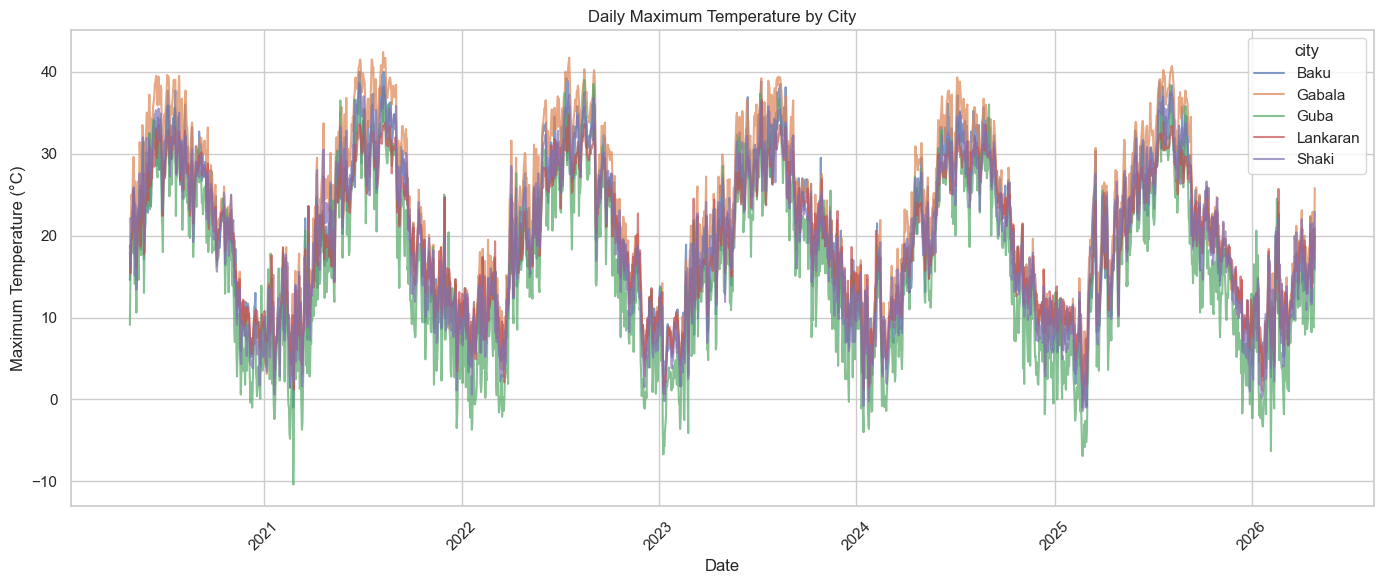

In [9]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df,
    x="time",
    y="temperature_2m_max",
    hue="city",
    alpha=0.7,
)

plt.title("Daily Maximum Temperature by City")
plt.xlabel("Date")
plt.ylabel("Maximum Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2 — monthly average temperature

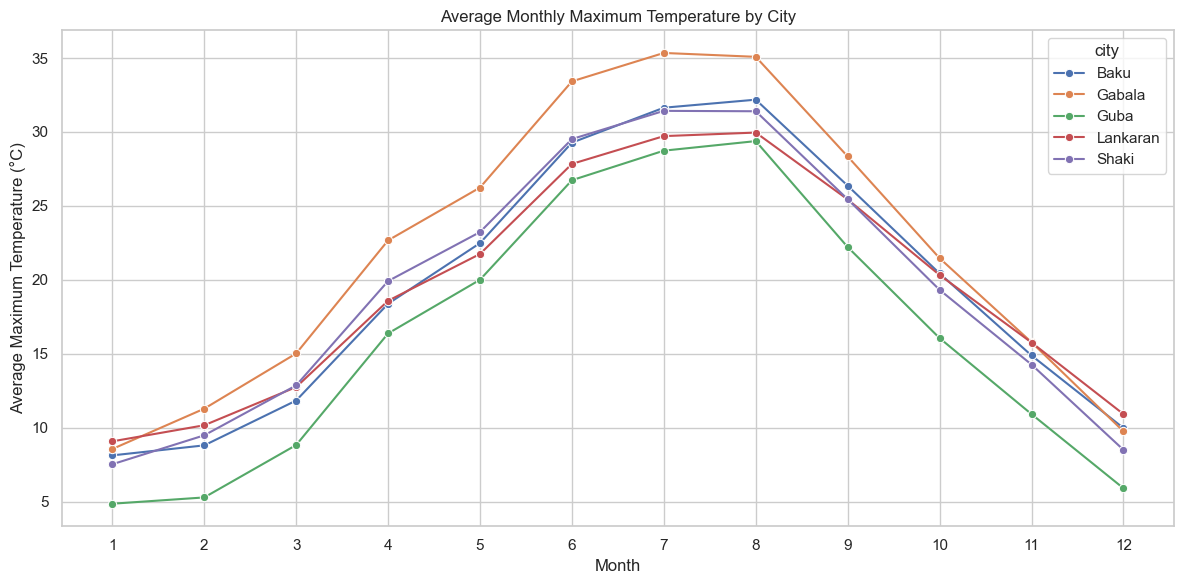

In [19]:
monthly_temp = (
    df.groupby(["city", "month"])["temperature_2m_max"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_temp,
    x="month",
    y="temperature_2m_max",
    hue="city",
    marker="o",
)

plt.title("Average Monthly Maximum Temperature by City")
plt.xlabel("Month")
plt.ylabel("Average Maximum Temperature (°C)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_temperature_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 — city comparison boxplots

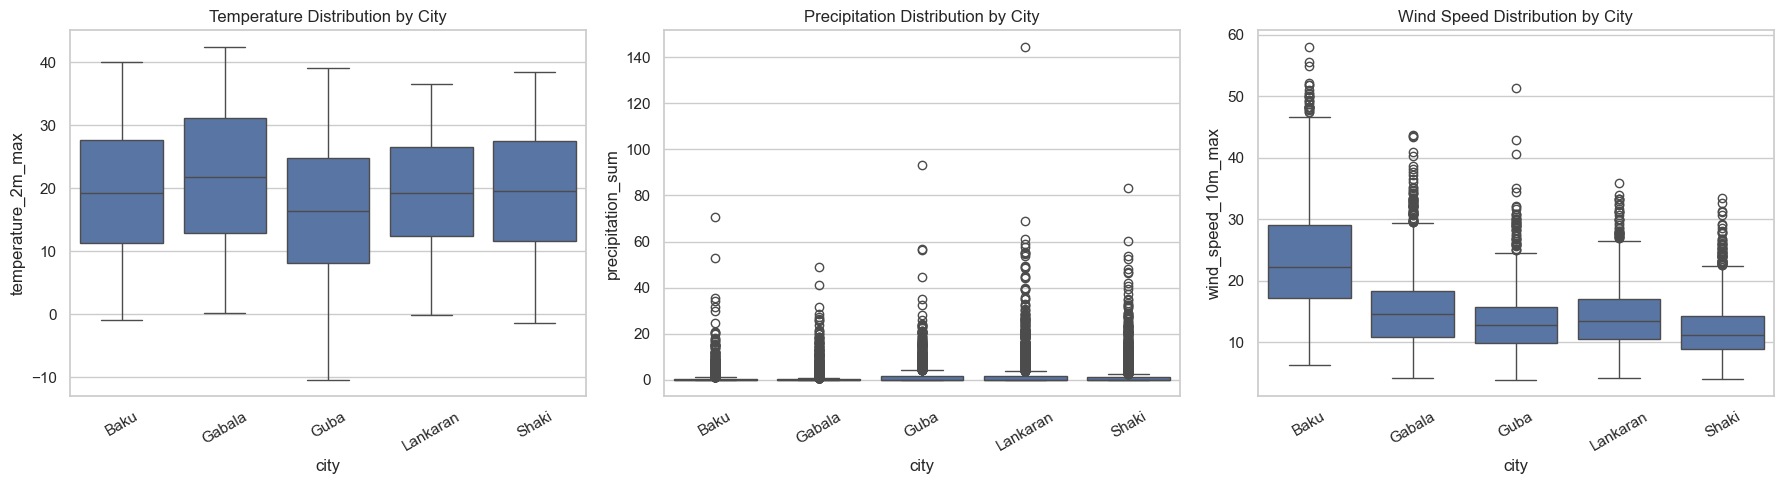

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="city", y="temperature_2m_max", ax=axes[0])
axes[0].set_title("Temperature Distribution by City")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="city", y="precipitation_sum", ax=axes[1])
axes[1].set_title("Precipitation Distribution by City")
axes[1].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="city", y="wind_speed_10m_max", ax=axes[2])
axes[2].set_title("Wind Speed Distribution by City")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "weather_distribution_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Analysis


### 7.1 — correlation matrix

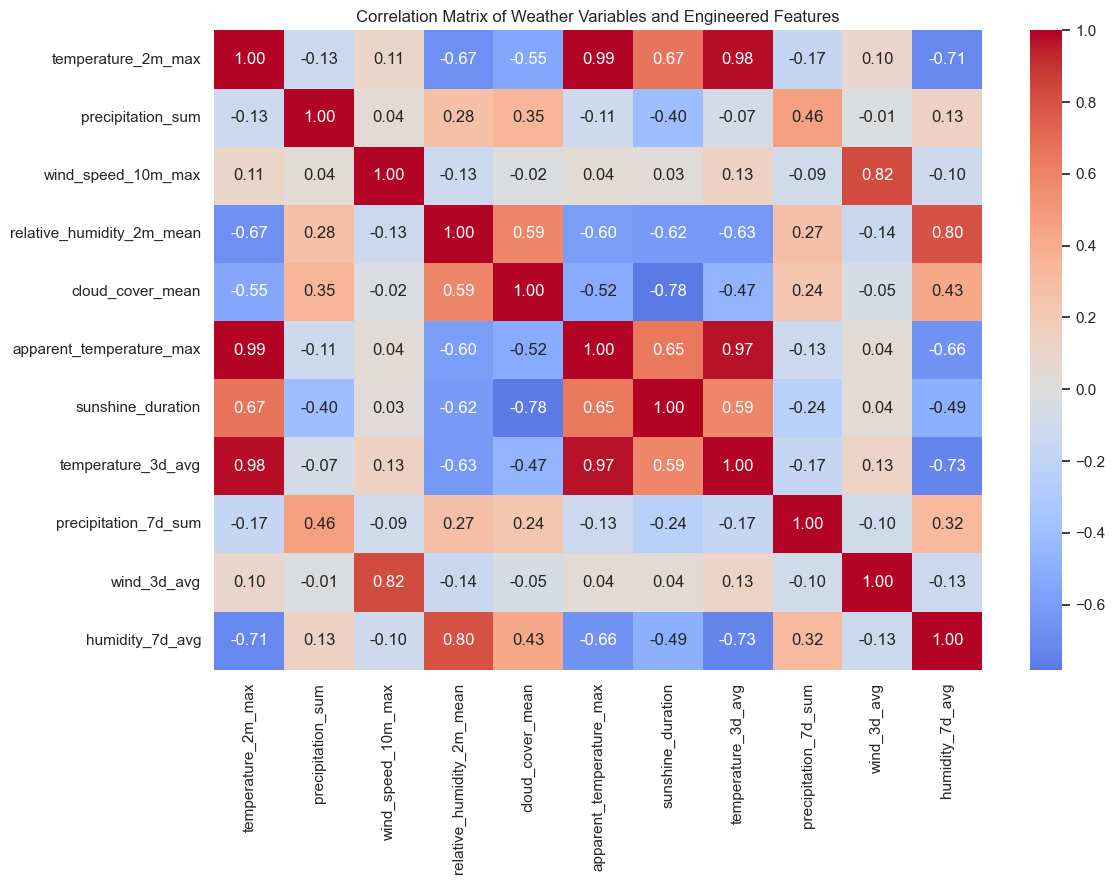

In [21]:
corr_cols = [
    "temperature_2m_max",
    "precipitation_sum",
    "wind_speed_10m_max",
    "relative_humidity_2m_mean",
    "cloud_cover_mean",
    "apparent_temperature_max",
    "sunshine_duration",
    "temperature_3d_avg",
    "precipitation_7d_sum",
    "wind_3d_avg",
    "humidity_7d_avg",
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation Matrix of Weather Variables and Engineered Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "weather_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.2 — top correlations with targets

In [13]:
target_corrs = corr_matrix[target_cols].drop(index=target_cols, errors="ignore")

for target in target_cols:
    print(f"\nTop correlations with {target}:")
    display(
        target_corrs[target]
        .abs()
        .sort_values(ascending=False)
        .head(5)
    )


Top correlations with temperature_2m_max:


apparent_temperature_max    0.989757
temperature_3d_avg          0.975853
humidity_7d_avg             0.708143
sunshine_duration           0.669096
precipitation_7d_sum        0.166167
Name: temperature_2m_max, dtype: float64


Top correlations with precipitation_sum:


precipitation_7d_sum        0.460842
sunshine_duration           0.404270
humidity_7d_avg             0.132241
apparent_temperature_max    0.107569
temperature_3d_avg          0.065812
Name: precipitation_sum, dtype: float64


Top correlations with wind_speed_10m_max:


wind_3d_avg                 0.824402
temperature_3d_avg          0.133791
humidity_7d_avg             0.104138
precipitation_7d_sum        0.093360
apparent_temperature_max    0.040996
Name: wind_speed_10m_max, dtype: float64


Top correlations with relative_humidity_2m_mean:


humidity_7d_avg             0.801639
temperature_3d_avg          0.626030
sunshine_duration           0.620708
apparent_temperature_max    0.601316
precipitation_7d_sum        0.272090
Name: relative_humidity_2m_mean, dtype: float64


Top correlations with cloud_cover_mean:


sunshine_duration           0.781420
apparent_temperature_max    0.524718
temperature_3d_avg          0.474346
humidity_7d_avg             0.428792
precipitation_7d_sum        0.240121
Name: cloud_cover_mean, dtype: float64

## 8. Hypothesis Testing


### 8.1 — temperature differs across cities

In [14]:
temperature_groups = [
    group["temperature_2m_max"].dropna()
    for _, group in df.groupby("city")
]

anova_stat, anova_p = f_oneway(*temperature_groups)

print("Hypothesis Test 1 — Temperature differs across cities")
print("H0: Mean maximum temperature is the same across all cities.")
print("H1: At least one city has a different mean maximum temperature.")
print(f"ANOVA statistic: {anova_stat:.4f}")
print(f"p-value: {anova_p:.6f}")

if anova_p < 0.05:
    print("Conclusion: Reject H0. Temperature differs significantly across cities.")
else:
    print("Conclusion: Fail to reject H0. No significant difference detected.")

Hypothesis Test 1 — Temperature differs across cities
H0: Mean maximum temperature is the same across all cities.
H1: At least one city has a different mean maximum temperature.
ANOVA statistic: 97.4049
p-value: 0.000000
Conclusion: Reject H0. Temperature differs significantly across cities.


### 8.2 — precipitation differs across cities

In [15]:
precipitation_groups = [
    group["precipitation_sum"].dropna()
    for _, group in df.groupby("city")
]

kruskal_stat, kruskal_p = kruskal(*precipitation_groups)

print("Hypothesis Test 2 — Precipitation differs across cities")
print("H0: Precipitation distribution is the same across all cities.")
print("H1: At least one city has a different precipitation distribution.")
print(f"Kruskal-Wallis statistic: {kruskal_stat:.4f}")
print(f"p-value: {kruskal_p:.6f}")

if kruskal_p < 0.05:
    print("Conclusion: Reject H0. Precipitation differs significantly across cities.")
else:
    print("Conclusion: Fail to reject H0. No significant difference detected.")

Hypothesis Test 2 — Precipitation differs across cities
H0: Precipitation distribution is the same across all cities.
H1: At least one city has a different precipitation distribution.
Kruskal-Wallis statistic: 228.7420
p-value: 0.000000
Conclusion: Reject H0. Precipitation differs significantly across cities.


### 8.3 — wind differs across cities

In [16]:
wind_groups = [
    group["wind_speed_10m_max"].dropna()
    for _, group in df.groupby("city")
]

wind_stat, wind_p = kruskal(*wind_groups)

print("Hypothesis Test 3 — Wind speed differs across cities")
print("H0: Wind speed distribution is the same across all cities.")
print("H1: At least one city has a different wind speed distribution.")
print(f"Kruskal-Wallis statistic: {wind_stat:.4f}")
print(f"p-value: {wind_p:.6f}")

if wind_p < 0.05:
    print("Conclusion: Reject H0. Wind speed differs significantly across cities.")
else:
    print("Conclusion: Fail to reject H0. No significant difference detected.")

Hypothesis Test 3 — Wind speed differs across cities
H0: Wind speed distribution is the same across all cities.
H1: At least one city has a different wind speed distribution.
Kruskal-Wallis statistic: 2988.3133
p-value: 0.000000
Conclusion: Reject H0. Wind speed differs significantly across cities.


## 9. Tourism-Relevant Insights


### 9.1 — simple comfort/risk flags

In [17]:
tourism_df = df.copy()

tourism_df["rain_risk"] = tourism_df["precipitation_sum"] > 1
tourism_df["strong_wind_risk"] = tourism_df["wind_speed_10m_max"] > 35
tourism_df["high_humidity_risk"] = tourism_df["relative_humidity_2m_mean"] > 80
tourism_df["cloudy_day"] = tourism_df["cloud_cover_mean"] > 70
tourism_df["comfortable_temp"] = tourism_df["temperature_2m_max"].between(18, 30)

tourism_risk_summary = tourism_df.groupby("city").agg(
    comfortable_temp_pct=("comfortable_temp", lambda x: x.mean() * 100),
    rain_risk_pct=("rain_risk", lambda x: x.mean() * 100),
    strong_wind_risk_pct=("strong_wind_risk", lambda x: x.mean() * 100),
    high_humidity_risk_pct=("high_humidity_risk", lambda x: x.mean() * 100),
    cloudy_day_pct=("cloudy_day", lambda x: x.mean() * 100),
).reset_index()

tourism_risk_summary

,city,comfortable_temp_pct,rain_risk_pct,strong_wind_risk_pct,high_humidity_risk_pct,cloudy_day_pct
0,Baku,36.649932,16.430853,10.862620,28.343222,32.998631
1,Gabala,33.409402,16.795984,0.547695,20.264719,25.832953
2,Guba,35.326335,30.625285,0.182565,29.301689,40.803286
3,Lankaran,44.135098,27.658603,0.045641,41.487905,37.608398
4,Shaki,38.886353,24.646280,0.000000,23.733455,29.803743


### 9.2 — May–June tourism suitability proxy

In [18]:
may_june_tourism = tourism_df[tourism_df["month"].isin([5, 6])].copy()

may_june_tourism_summary = may_june_tourism.groupby("city").agg(
    comfortable_temp_pct=("comfortable_temp", lambda x: x.mean() * 100),
    rain_risk_pct=("rain_risk", lambda x: x.mean() * 100),
    strong_wind_risk_pct=("strong_wind_risk", lambda x: x.mean() * 100),
    high_humidity_risk_pct=("high_humidity_risk", lambda x: x.mean() * 100),
    cloudy_day_pct=("cloudy_day", lambda x: x.mean() * 100),
).reset_index()

may_june_tourism_summary.sort_values("comfortable_temp_pct", ascending=False)

,city,comfortable_temp_pct,rain_risk_pct,strong_wind_risk_pct,high_humidity_risk_pct,cloudy_day_pct
3,Lankaran,83.606557,20.765027,0.000000,33.879781,21.311475
4,Shaki,72.404372,34.972678,0.000000,9.016393,23.497268
0,Baku,69.945355,14.754098,11.748634,4.371585,15.573770
2,Guba,68.032787,31.967213,0.000000,11.202186,30.054645
1,Gabala,44.808743,19.945355,0.546448,2.732240,17.759563


<Figure size 1200x600 with 0 Axes>

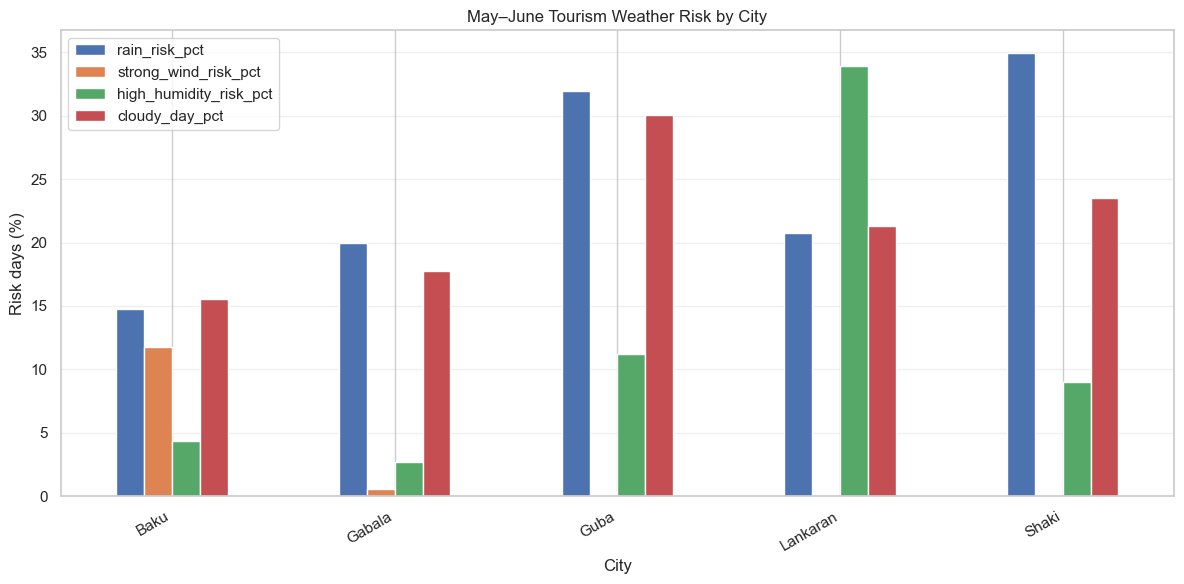

In [22]:
risk_cols = [
    "rain_risk_pct",
    "strong_wind_risk_pct",
    "high_humidity_risk_pct",
    "cloudy_day_pct",
]

risk_plot_df = may_june_tourism_summary.set_index("city")[risk_cols]

plt.figure(figsize=(12, 6))
risk_plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("May–June Tourism Weather Risk by City")
plt.xlabel("City")
plt.ylabel("Risk days (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(FIGURES_DIR / "may_june_tourism_risk_by_city.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Save Key Figures

Key figures were saved directly inside the plotting cells using `plt.savefig()`.

Saved outputs:

- `monthly_temperature_by_city.png`
- `weather_distribution_by_city.png`
- `weather_correlation_matrix.png`
- `may_june_tourism_risk_by_city.png`

## 11. EDA Summary

The EDA shows clear differences between cities in temperature, precipitation, wind, humidity, and cloud cover.

Key findings:

- Temperature patterns are strongly seasonal.
- Cities differ meaningfully in their average weather conditions.
- Precipitation and wind risks vary by location.
- May–June is a useful seasonal window for tourism planning.
- Correlation analysis confirms that engineered rolling features capture recent weather trends.
- Hypothesis tests support that weather conditions differ significantly across cities.

These insights support the modeling stage and the future activity suitability layer.